# 03 · Behaviour Over Time (movement)

The general pose/behavioural time series, per trial and per segment (whole / outbound /
inbound), all driven by `movement`:

| quantity | how | 
|---|---|
| head direction | `compute_forward_vector_angle(lear, rear, top_down)` (deg) |
| angular head velocity | time derivative of the (unwrapped) head direction (deg/s) |
| speed | `compute_speed` on the body centroid (px/s) |
| displacement from start | distance of the centroid to its segment-start position (px) |

We show (a) example over-time traces for one trial, and (b) per-trial summaries
(mean/peak speed, mean |angular head velocity|, net displacement, duration) distributed by
outcome.

> **Kernel:** repo `.venv`. Run `01_summary_table.ipynb` first.

## 0 · Setup and config

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

WORKSPACE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(WORKSPACE) not in sys.path:
    sys.path.insert(0, str(WORKSPACE))

from pose_trajectory import workspace
from pose_trajectory.loading import select_pose_sessions, session_movement_dataset
from data_conduit.utils.utils_core import exclude  # 'all but these' selector

# movement = the analysis.
from movement.filtering import filter_by_confidence
from movement.kinematics import compute_forward_vector_angle, compute_speed

pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore")

In [2]:
# ============================== EDIT THESE (match notebook 01) ==============================
DATA_ROOT = workspace.REPO_ROOT / "datasets" / "firstdata" / "BonsaiFiles"
MICE     = ["FbR_M01569522"]   # include list | exclude("X", ...) for all-but | None = all
DAYS     = ["Day 11"]          # exact day-folder names (note "Day 11" and "Day_11" both exist)
SESSIONS = None                # session-folder names to include, or None for all

CONFIDENCE_MIN = 0.9     # blank DLC detections below this likelihood
LEFT_EAR, RIGHT_EAR = "lear", "rear"   # head-direction keypoints (camera is top-down)
# ===========================================================================================

sessions = select_pose_sessions(DATA_ROOT, mice=MICE, days=DAYS, sessions=SESSIONS, require_dlc=True)

# These notebooks write per-mouse outputs, so resolve the single selected mouse for the
# summary-table lookup and the output filenames. Select exactly one mouse above.
_mice = sorted({entry["mouse"] for entry in sessions.values()})
assert len(_mice) == 1, f"Select exactly one mouse for this notebook; selection has {_mice}"
MOUSE_ID = _mice[0]

summary = pd.read_csv(workspace.OUTPUT_DIR / f"summary_table_{MOUSE_ID}.csv")

SEGMENTS = {
    "whole":    ("outbound_start", "inbound_end"),
    "outbound": ("outbound_start", "outbound_end"),
    "inbound":  ("inbound_start",  "inbound_end"),
}
print(f"{len(summary)} trials | {len(sessions)} sessions")

109 trials | 6 sessions


## 1 · Per-session time series

For one session, `session_series` returns the head-direction angle, the angular head
velocity, the centroid speed, and the centroid itself, all on the session clock. Head
direction is a `movement` call; angular head velocity is the time derivative of the
**unwrapped** head direction (unwrapping avoids spurious jumps when the angle crosses
±180°).

In [3]:
def session_series(session_dir):
    """Return (centroid, head_direction_deg, ahv_deg_s, speed_px_s) for one session."""
    mov = session_movement_dataset(session_dir)
    clean = filter_by_confidence(mov["position"], mov["confidence"], threshold=CONFIDENCE_MIN, print_report=False)
    centroid = clean.mean("keypoint")

    # movement: head direction as the angle of the ear-pair forward vector (degrees).
    hd = compute_forward_vector_angle(clean, left_keypoint=LEFT_EAR, right_keypoint=RIGHT_EAR,
                                      camera_view="top_down", in_degrees=True)
    # Angular head velocity: derivative of the unwrapped angle w.r.t. time (deg/s).
    times = hd["time"].values
    unwrapped = np.unwrap(hd.values, period=360, axis=hd.get_axis_num("time"))
    ahv = xr.DataArray(np.gradient(unwrapped, times, axis=hd.get_axis_num("time")),
                       coords=hd.coords, dims=hd.dims)

    # movement: centroid speed (px/s).
    speed = compute_speed(centroid)
    return centroid, hd, ahv, speed

## 2 · Example over-time traces for one trial

Pick a session and a trial; the four panels show head direction, angular head velocity,
speed, and displacement-from-start across that trial, with the outbound→inbound boundary
(target-zone trigger) marked.

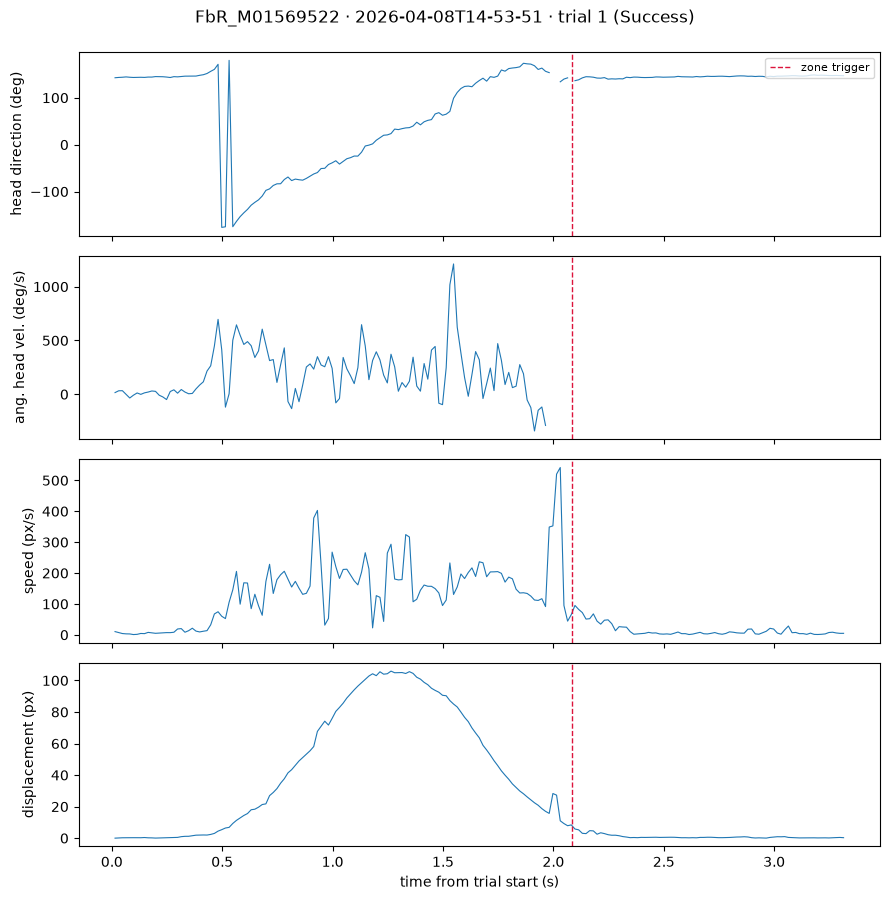

In [4]:
# ---- choose the example trial ----
EXAMPLE_SESSION = list(sessions)[0]
EXAMPLE_TRIAL = 1                 # trial_in_session
# ----------------------------------

row = summary[(summary["session"] == EXAMPLE_SESSION) & (summary["trial_in_session"] == EXAMPLE_TRIAL)].iloc[0]
centroid, hd, ahv, speed = session_series(sessions[EXAMPLE_SESSION]["path"])

# whole-trial window, and the zone-trigger time that splits outbound from inbound
t0, t1, t_split = row["outbound_start"], row["inbound_end"], row["inbound_start"]
win = slice(t0, t1)

cseg = centroid.sel(time=win)
rel_t = cseg["time"].values - t0                                  # seconds from trial start
disp = np.sqrt(((cseg - cseg.isel(time=0)) ** 2).sum("space")).squeeze().values

fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)
series = [
    (hd.sel(time=win).squeeze().values,    "head direction (deg)"),
    (ahv.sel(time=win).squeeze().values,   "ang. head vel. (deg/s)"),
    (speed.sel(time=win).squeeze().values, "speed (px/s)"),
    (disp,                                 "displacement (px)"),
]
for ax, (y, label) in zip(axes, series):
    ax.plot(rel_t, y, lw=0.8)
    ax.axvline(t_split - t0, color="crimson", ls="--", lw=1, label="zone trigger")
    ax.set_ylabel(label)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time from trial start (s)")
fig.suptitle(f"{MOUSE_ID} · {EXAMPLE_SESSION} · trial {EXAMPLE_TRIAL} ({row['result']})", y=0.995)
fig.tight_layout()
workspace.save_figure(fig, f"behaviour_traces_{MOUSE_ID}_{EXAMPLE_SESSION}_t{EXAMPLE_TRIAL}")
plt.show()

## 3 · Per-trial behaviour summaries

For every trial and segment, reduce the time series to scalars: duration, mean and peak
speed, mean absolute angular head velocity, and net displacement (start→end straight-line
distance).

In [5]:
def segment_behaviour(centroid, ahv, speed, t0, t1):
    """Scalar behaviour summaries for one segment [t0, t1] (seconds)."""
    if not np.isfinite([t0, t1]).all():
        return dict(duration_s=np.nan, mean_speed=np.nan, peak_speed=np.nan,
                    mean_abs_ahv=np.nan, net_displacement=np.nan, n_frames=0)
    win = slice(t0, t1)
    cseg = centroid.sel(time=win)
    n = int(cseg.sizes["time"])
    if n < 2:
        return dict(duration_s=float(t1 - t0), mean_speed=np.nan, peak_speed=np.nan,
                    mean_abs_ahv=np.nan, net_displacement=np.nan, n_frames=n)
    sp = speed.sel(time=win).values
    av = ahv.sel(time=win).values
    net = float(np.sqrt(((cseg.isel(time=-1) - cseg.isel(time=0)) ** 2).sum("space")).squeeze().values)
    return dict(
        duration_s=float(t1 - t0),
        mean_speed=float(np.nanmean(sp)),
        peak_speed=float(np.nanmax(sp)),
        mean_abs_ahv=float(np.nanmean(np.abs(av))),
        net_displacement=net,
        n_frames=n,
    )


records = []
for key, entry in sessions.items():
    centroid, hd, ahv, speed = session_series(entry["path"])
    for _, trow in summary[summary["session"] == key].iterrows():
        for seg_name, (c0, c1) in SEGMENTS.items():
            b = segment_behaviour(centroid, ahv, speed, trow[c0], trow[c1])
            records.append({"session": key, "day": trow["day"],
                            "trial_in_session": trow["trial_in_session"], "trial_in_day": trow["trial_in_day"],
                            "result": trow["result"], "segment": seg_name, **b})

behaviour = pd.DataFrame.from_records(records)
print("rows:", len(behaviour))
behaviour.head(9)

rows: 327


,session,day,trial_in_session,trial_in_day,result,segment,duration_s,mean_speed,peak_speed,mean_abs_ahv,net_displacement,n_frames
0,2026-04-08T14-53-51,Day 11,1,1,Success,whole,3.327008,92.646354,541.545154,222.37409,0.293716,199
1,2026-04-08T14-53-51,Day 11,1,1,Success,outbound,2.084000,138.725893,541.545154,222.37409,8.396785,125
2,2026-04-08T14-53-51,Day 11,1,1,Success,inbound,1.243008,14.809295,95.084675,NaN,5.531910,74
3,2026-04-08T14-53-51,Day 11,2,2,Success,whole,6.442496,53.472994,446.493533,NaN,12.372293,387
4,2026-04-08T14-53-51,Day 11,2,2,Success,outbound,5.408000,50.235438,432.731829,NaN,42.029337,325
5,2026-04-08T14-53-51,Day 11,2,2,Success,inbound,1.034496,70.444049,446.493533,NaN,32.247450,62
6,2026-04-08T14-53-51,Day 11,3,3,Success,whole,5.259008,63.652049,383.601331,NaN,7.464083,315
7,2026-04-08T14-53-51,Day 11,3,3,Success,outbound,4.448480,66.235581,360.210175,NaN,21.223438,267
8,2026-04-08T14-53-51,Day 11,3,3,Success,inbound,0.810528,49.281150,383.601331,NaN,16.043567,48


## 4 · Distributions by outcome (Success / Fail / Miss)

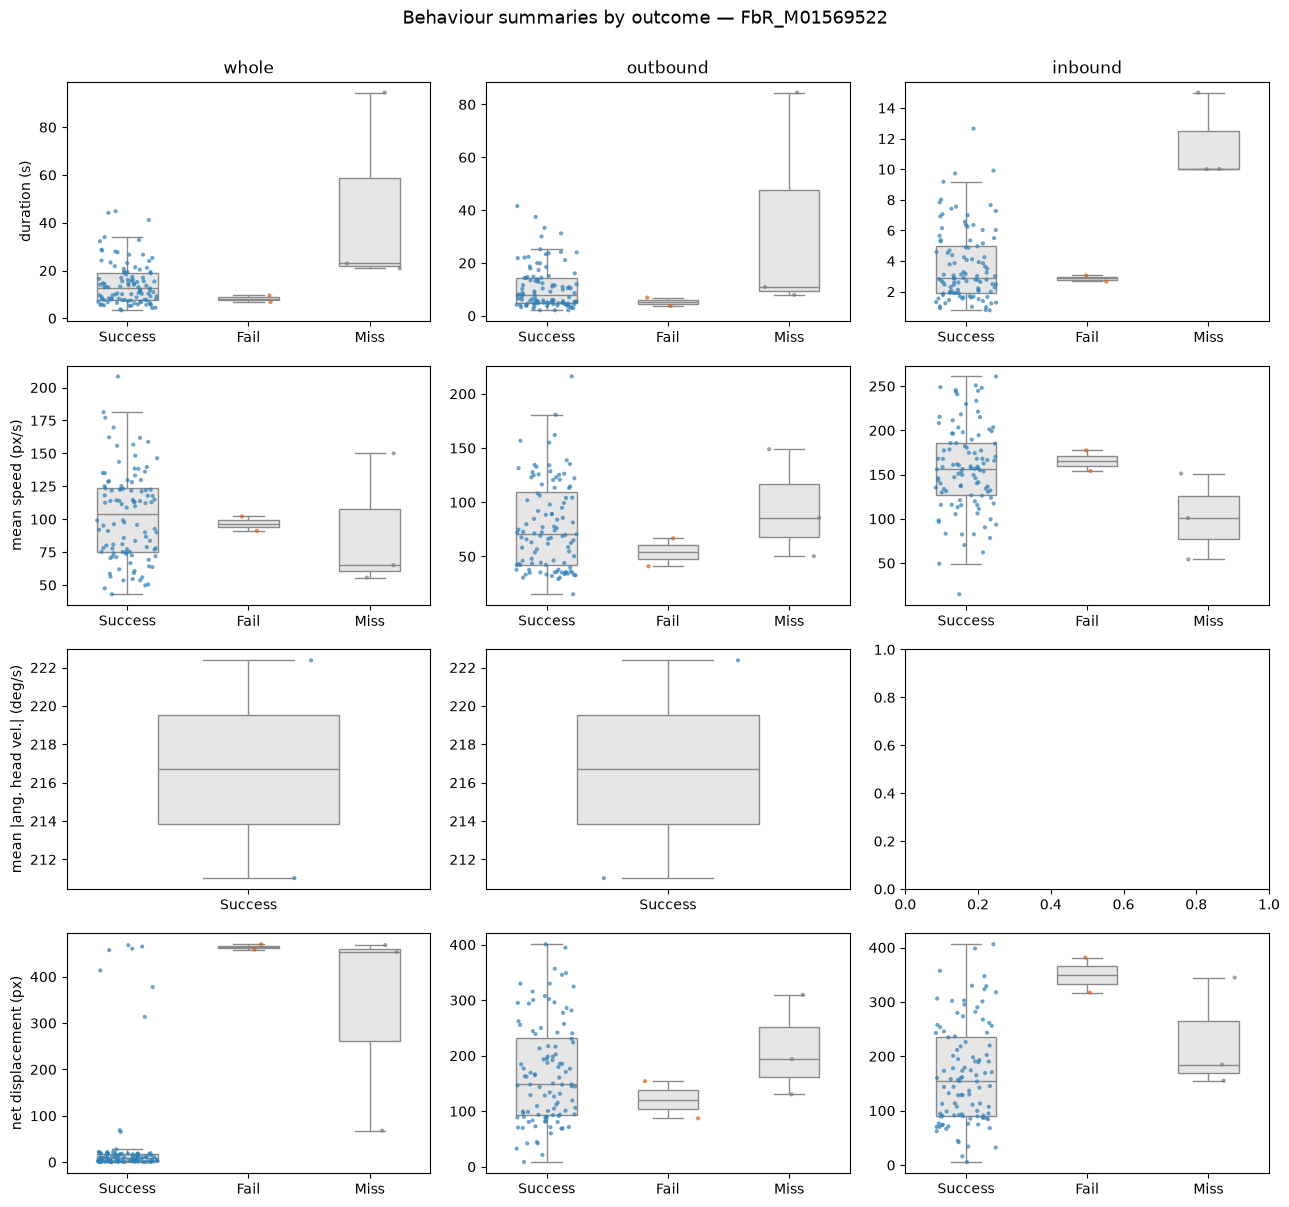

In [6]:
SEG_ORDER = ["whole", "outbound", "inbound"]
RESULT_ORDER = ["Success", "Fail", "Miss"]
PALETTE = {"Success": "#2c7fb8", "Fail": "#d95f0e", "Miss": "#7a7a7a"}


def distribution_grid(df, metric_labels, title, fname):
    """Grid of metric (rows) x segment (cols) distributions, split by outcome.

    A box for the spread plus a jittered point per trial coloured by outcome. NaNs are
    dropped per panel and only outcome categories that actually have data are drawn, so
    rare Fail/Miss outcomes never break the plot.
    """
    fig, axes = plt.subplots(len(metric_labels), len(SEG_ORDER),
                             figsize=(13, 3 * len(metric_labels)), squeeze=False)
    for r, (metric, label) in enumerate(metric_labels.items()):
        for c, seg in enumerate(SEG_ORDER):
            ax = axes[r][c]
            sub = df[df["segment"] == seg].dropna(subset=[metric])
            present = [res for res in RESULT_ORDER if (sub["result"] == res).any()]
            if present:
                sns.boxplot(data=sub, x="result", y=metric, order=present, ax=ax,
                            showfliers=False, width=0.5, color="0.9")
                sns.stripplot(data=sub, x="result", y=metric, order=present, ax=ax,
                              hue="result", palette=PALETTE, legend=False, size=3, jitter=0.25, alpha=0.7)
            ax.set_xlabel("")
            ax.set_ylabel(label if c == 0 else "")
            if r == 0:
                ax.set_title(seg)
    fig.suptitle(title, y=1.002, fontsize=13)
    fig.tight_layout()
    workspace.save_figure(fig, fname)
    plt.show()


METRIC_LABELS = {
    "duration_s": "duration (s)",
    "mean_speed": "mean speed (px/s)",
    "mean_abs_ahv": "mean |ang. head vel.| (deg/s)",
    "net_displacement": "net displacement (px)",
}
distribution_grid(behaviour, METRIC_LABELS, f"Behaviour summaries by outcome — {MOUSE_ID}", f"behaviour_summaries_{MOUSE_ID}")

In [7]:
out_path = workspace.OUTPUT_DIR / f"behaviour_summaries_{MOUSE_ID}.csv"
behaviour.to_csv(out_path, index=False)
print("saved:", out_path)

saved: /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Pose_Trajectory_Analysis/outputs/behaviour_summaries_FbR_M01569522.csv
